# Text Embedding Sanity Check
Find the most similar items by **text** cosine similarity and display their images.

If the multilingual text embeddings are working correctly:
- Same-label items should have high cosine similarity (> 0.8)
- Top neighbours should be visually and semantically similar products
- Items from different languages but describing the same product should cluster together

In [1]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os
import random

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_FOLDER   = "../data/"
IMAGES_FOLDER = "../../images/"   # DO NOT LIST — open per-item only
TEXT_EMB_PATH = "text_embeddings.pt"

# ── Load text embeddings ──────────────────────────────────────────────────────
print("Loading text embeddings...")
text_emb_raw = torch.load(TEXT_EMB_PATH, map_location="cpu", weights_only=False)
sample_key = next(iter(text_emb_raw))
EMB_DIM = text_emb_raw[sample_key].shape[0]
print(f"  {len(text_emb_raw):,} embeddings  |  key type: {type(sample_key).__name__}  |  dim: {EMB_DIM}")

# ── Load item metadata ────────────────────────────────────────────────────────
print("Loading item metadata...")
df = pd.read_csv(os.path.join(DATA_FOLDER, "items_train.csv"))
df["itemId_str"]   = df["itemId"].astype(str)
df["title"]        = df["title"].fillna("")
df["description"]  = df["description"].fillna("")
df["text"]         = (df["title"] + " " + df["description"]).str.strip()

# Keep only items that have a text embedding
df = df[df["itemId_str"].isin({str(k) for k in text_emb_raw.keys()})].reset_index(drop=True)
print(f"  Items with text embeddings: {len(df):,}")


Loading text embeddings...
  1,128,069 embeddings  |  key type: str  |  dim: 512
Loading item metadata...
  Items with text embeddings: 928,234


In [2]:
# ── Build normalised text embedding matrix ────────────────────────────────────
print("Building text embedding matrix...")
item_ids = df["itemId_str"].tolist()

def _get_emb(iid):
    v = text_emb_raw.get(iid)
    if v is None:
        v = text_emb_raw.get(int(iid))
    return v

text_matrix = torch.stack([_get_emb(iid) for iid in item_ids]).float()  # (N, D)
text_matrix = F.normalize(text_matrix, dim=1)                            # unit norm → dot = cosine sim
print(f"  Text embedding matrix: {text_matrix.shape}  (normalised)")


Building text embedding matrix...
  Text embedding matrix: torch.Size([928234, 512])  (normalised)


In [3]:
def find_text_neighbours(query_idx, text_matrix, top_k=6, exclude_self=True):
    """Return indices and cosine similarities of top-k text-nearest neighbours."""
    sims = torch.mv(text_matrix, text_matrix[query_idx])
    if exclude_self:
        sims[query_idx] = -1.0
    top_sims, top_idx = torch.topk(sims, top_k)
    return top_idx.numpy(), top_sims.numpy()


def load_image(item_id):
    path = os.path.join(IMAGES_FOLDER, f"{item_id}.jpg")
    try:
        return Image.open(path).convert("RGB")
    except Exception:
        return None


def show_text_neighbours(query_idx, text_matrix, df, top_k=6, text_chars=80):
    """Show query item and its top-k text-similar neighbours with their images."""
    nn_idx, nn_sims = find_text_neighbours(query_idx, text_matrix, top_k=top_k)

    query_row    = df.iloc[query_idx]
    rows_to_show = [query_row] + [df.iloc[i] for i in nn_idx]
    sim_labels   = ["QUERY"]  + [f"sim={s:.3f}" for s in nn_sims]
    is_query_col = [True]     + [False] * top_k

    n_cols = len(rows_to_show)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 7))

    for ax, row, sim_label, is_query in zip(axes, rows_to_show, sim_labels, is_query_col):
        iid = str(row["itemId"])
        img = load_image(iid)

        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "no image", ha="center", va="center",
                    fontsize=9, transform=ax.transAxes)
            ax.set_facecolor("#eeeeee")

        query_label   = query_row["label"]
        is_same_label = (not is_query) and (row["label"] == query_label)

        border_color = "#1565C0" if is_query else ("#2e7d32" if is_same_label else "#c62828")
        lw = 4 if is_query else 3
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(lw)

        title_short = str(row["title"])[:text_chars]
        geo   = str(row.get("geo", ""))
        price = row.get("price", "")

        ax.set_title(f"{sim_label}\n{title_short}\n{geo} | {price}\nlabel={row['label']}",
                     fontsize=8, pad=5)
        ax.set_xticks([])
        ax.set_yticks([])

    patches = [
        mpatches.Patch(color="#1565C0", label="Query"),
        mpatches.Patch(color="#2e7d32", label="Same label (true duplicate)"),
        mpatches.Patch(color="#c62828", label="Different label"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
               bbox_to_anchor=(0.5, -0.05))

    query_title = str(query_row["title"])[:60]
    fig.suptitle(
        f"Query: itemId={query_row['itemId']}  geo={query_row.get('geo', '')}  label={query_row['label']}\n\"{query_title}\"",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # Also print the full texts for comparison
    print(f"\n{'='*80}")
    print(f"QUERY text: {str(query_row['text'])[:200]}")
    print(f"{'─'*80}")
    for i, (idx, sim) in enumerate(zip(nn_idx, nn_sims)):
        row = df.iloc[idx]
        print(f"[{i+1}] sim={sim:.4f}  geo={row.get('geo','')}  label={row['label']}")
        print(f"     {str(row['text'])[:200]}")
    print()


print("Functions defined!")


Functions defined!


Query: index=221847  itemId=1314971  geo=hu


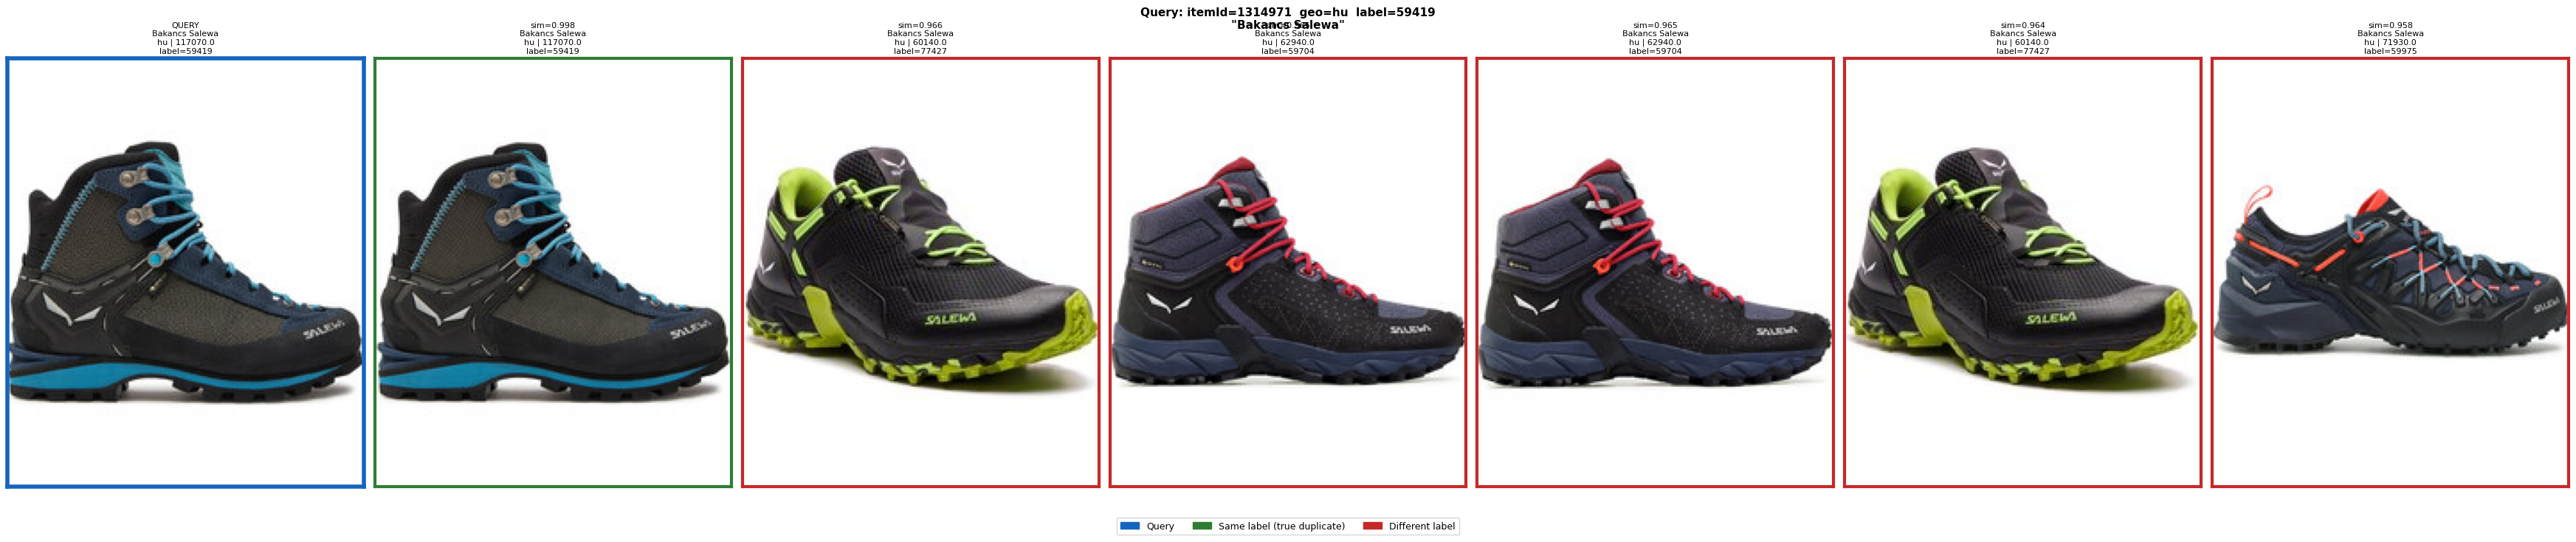


QUERY text: Bakancs Salewa Bakancs Salewa Crow Gtx GORE-TEX 61329-3985 Fekete
────────────────────────────────────────────────────────────────────────────────
[1] sim=0.9984  geo=hu  label=59419
     Bakancs Salewa Salewa Bakancs Crow Gtx GORE-TEX 61329-3985 Fekete
[2] sim=0.9657  geo=hu  label=77427
     Bakancs Salewa Bakancs Salewa Speed Beat Gtx GORE-TEX 61338-0978 Fekete
[3] sim=0.9650  geo=hu  label=59704
     Bakancs Salewa Bakancs Salewa Ws Alpenrose 2 Mid Gtx GORE-TEX 61374-0988 Sötétkék
[4] sim=0.9650  geo=hu  label=59704
     Bakancs Salewa Salewa Bakancs Ws Alpenrose 2 Mid Gtx GORE-TEX 61374-0988 Sötétkék
[5] sim=0.9645  geo=hu  label=77427
     Bakancs Salewa Salewa Bakancs Speed Beat Gtx GORE-TEX 61338-0978 Fekete
[6] sim=0.9575  geo=hu  label=59975
     Bakancs Salewa Bakancs Salewa Ws Wildfire Edge Gtx GORE-TEX 61376-3965 Sötétkék



In [16]:
# ── Random query ─────────────────────────────────────────────────────────────
random.seed()
query_idx = random.randint(0, len(df) - 1)
print(f"Query: index={query_idx}  itemId={df.iloc[query_idx]['itemId']}  geo={df.iloc[query_idx]['geo']}")
show_text_neighbours(query_idx, text_matrix, df, top_k=6)


Labels appearing in ≥2 geos: 61,509

Chosen label=248  —  8 items across geos: ['bg', 'bg', 'ro', 'ro', 'sk', 'sk', 'hu', 'hu']


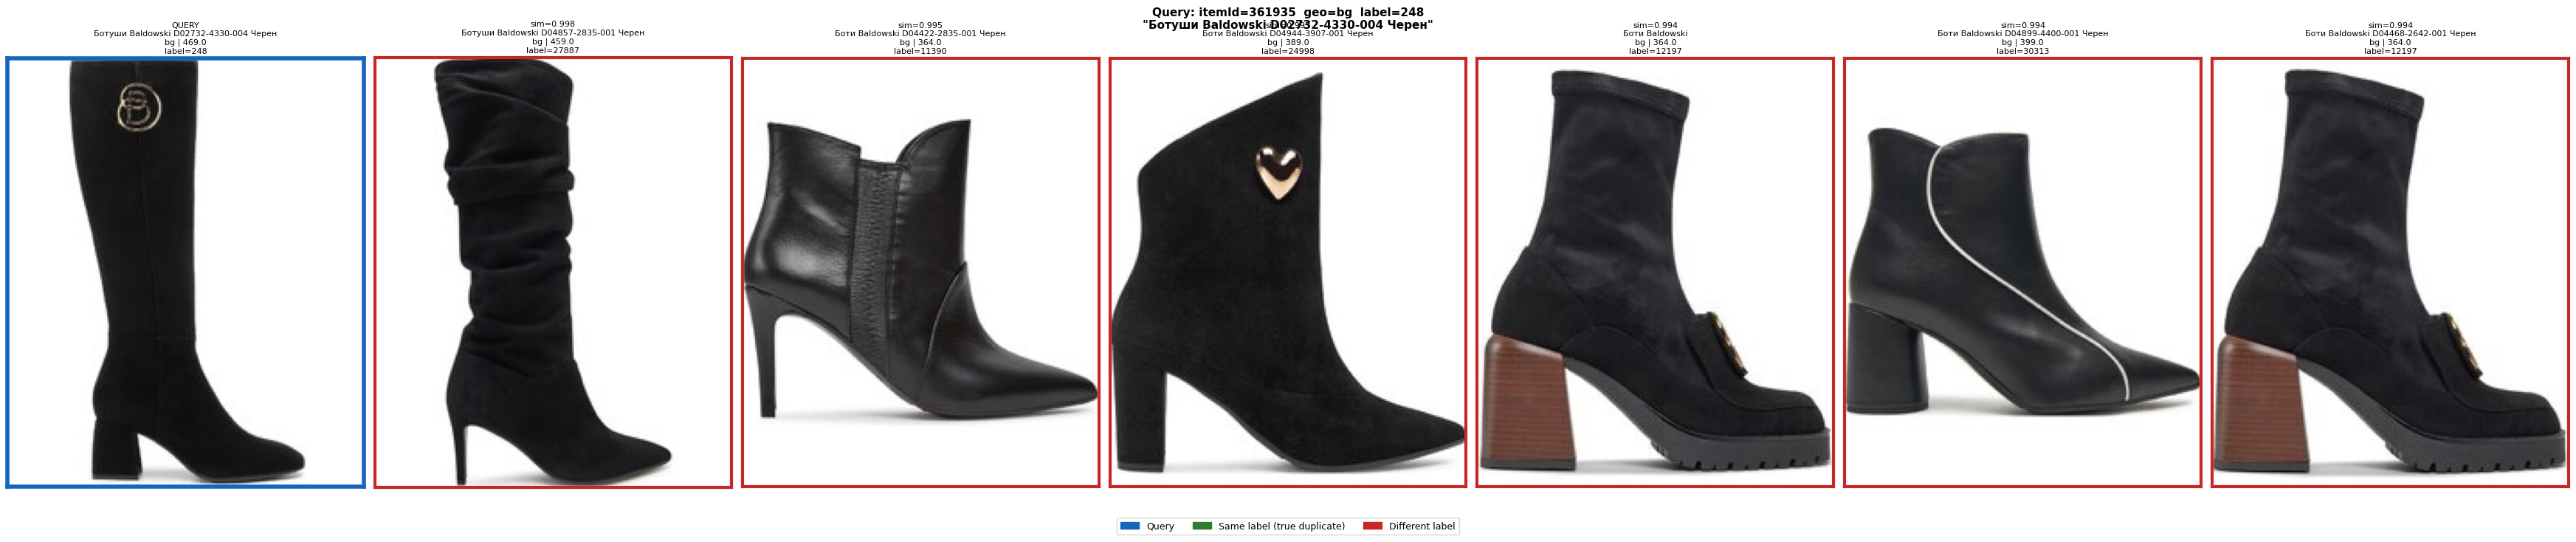


QUERY text: Ботуши Baldowski D02732-4330-004 Черен
────────────────────────────────────────────────────────────────────────────────
[1] sim=0.9982  geo=bg  label=27887
     Ботуши Baldowski D04857-2835-001 Черен
[2] sim=0.9949  geo=bg  label=11390
     Боти Baldowski D04422-2835-001 Черен
[3] sim=0.9946  geo=bg  label=24998
     Боти Baldowski D04944-3907-001 Черен
[4] sim=0.9944  geo=bg  label=12197
     Боти Baldowski Baldowski Боти D04468-2642-001 Черен
[5] sim=0.9942  geo=bg  label=30313
     Боти Baldowski D04899-4400-001 Черен
[6] sim=0.9940  geo=bg  label=12197
     Боти Baldowski D04468-2642-001 Черен



In [17]:
# ── Cross-lingual check: pick an item, find neighbours across different geos ──
# This is the key test — does the multilingual model link the same product
# across Czech, Slovak, Hungarian, Romanian etc. descriptions?

# Find a label that appears in multiple geos
label_geo = df.groupby("label")["geo"].nunique()
multi_geo_labels = label_geo[label_geo >= 2].index.tolist()
print(f"Labels appearing in ≥2 geos: {len(multi_geo_labels):,}")

# Pick a random one and query from one geo
random.seed(7)
chosen_label = random.choice(multi_geo_labels[:500])
label_items  = df[df["label"] == chosen_label]
print(f"\nChosen label={chosen_label}  —  {len(label_items)} items across geos: {label_items['geo'].tolist()}")

# Query from the first item
query_idx = label_items.index[0]
show_text_neighbours(query_idx, text_matrix, df, top_k=6)


Over 300 random queries, top-8 TEXT neighbours:
  Mean same-label neighbours : 1.65 / 8
  Queries with ≥1 same-label : 82.0%
  Queries with ≥3 same-label : 21.3%
  Queries with 0 same-label  : 18.0%


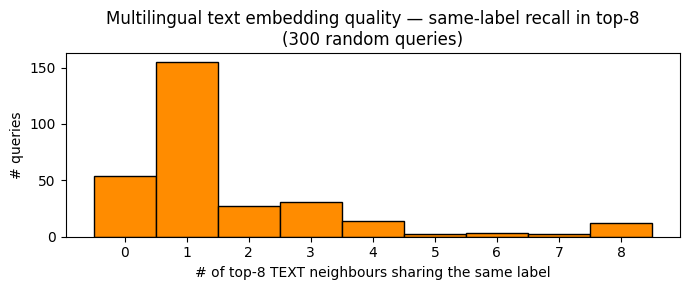

In [18]:
# ── Bulk stats: same-label recall in top-k text neighbours ───────────────────
N_QUERIES = 300
TOP_K     = 8
random.seed(0)
query_indices = random.sample(range(len(df)), N_QUERIES)

same_label_hits = []
for qi in query_indices:
    nn_idx, _ = find_text_neighbours(qi, text_matrix, top_k=TOP_K)
    query_label = df.iloc[qi]["label"]
    hits = sum(1 for i in nn_idx if df.iloc[i]["label"] == query_label)
    same_label_hits.append(hits)

hits_arr = np.array(same_label_hits)
print(f"Over {N_QUERIES} random queries, top-{TOP_K} TEXT neighbours:")
print(f"  Mean same-label neighbours : {hits_arr.mean():.2f} / {TOP_K}")
print(f"  Queries with ≥1 same-label : {(hits_arr >= 1).mean():.1%}")
print(f"  Queries with ≥3 same-label : {(hits_arr >= 3).mean():.1%}")
print(f"  Queries with 0 same-label  : {(hits_arr == 0).mean():.1%}")

plt.figure(figsize=(7, 3))
plt.hist(hits_arr, bins=range(TOP_K + 2), align="left", edgecolor="black", color="darkorange")
plt.xlabel(f"# of top-{TOP_K} TEXT neighbours sharing the same label")
plt.ylabel("# queries")
plt.title(f"Multilingual text embedding quality — same-label recall in top-{TOP_K}\n({N_QUERIES} random queries)")
plt.xticks(range(TOP_K + 1))
plt.tight_layout()
plt.show()
